In [12]:
# Load the "autoreload" extension so that code can change
%load_ext autoreload

# Reload modules so that as you change code in src, it gets loaded
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
 from cuml.neighbors import NearestNeighbors

ModuleNotFoundError: No module named 'cuml'

In [13]:
import stackprinter
stackprinter.set_excepthook(style='darkbg2')

In [14]:
from pathlib import Path
from typing import Final, Literal

import re
import gseapy as gp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import sparse
from anndata import AnnData
from loguru import logger
from matplotlib import colormaps
from scipy.sparse import issparse
from rich.progress import Progress

MAX_PVAL: Final[float] = 0.05

In [15]:
import muon as mu
from muon import prot as pt

In [4]:
mdata = mu.read_10x_h5(Path().home().joinpath("workspace", "scorphan", "tests", "5k_pbmc_protein_v3_filtered_feature_bc_matrix.h5"))

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:947: Us

In [5]:
mdata_raw = mu.read_10x_h5(Path().home().joinpath("workspace", "scorphan", "tests", "5k_pbmc_protein_v3_raw_feature_bc_matrix.h5"))

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:947: Us

In [6]:
pt.pp.dsb(data=mdata, data_raw=mdata_raw, empty_counts_range=(1.5, 2.8), isotype_controls=mdata_raw['prot'].var_names[29:32].values)

/tmp/ipykernel_30168/202865562.py:1: DeprecationWarning: empty_counts_range will be deprecated in the future versions
  pt.pp.dsb(data=mdata, data_raw=mdata_raw, empty_counts_range=(1.5, 2.8), isotype_controls=mdata_raw['prot'].var_names[29:32].values)
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/muon/_prot/preproc.py:137: UserWarning: Dropping 49 empty droplets as they are already defined as cells
  warn(


In [7]:
mdata.var_names_make_unique()
mdata['rna'].var['mt'] = mdata['rna'].var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'

In [8]:
sc.pp.calculate_qc_metrics(mdata['rna'], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
mu.pp.filter_var(mdata['rna'], 'n_cells_by_counts', lambda x: x >= 3)
mu.pp.filter_obs(mdata['rna'], 'n_genes_by_counts', lambda x: (x >= 200) & (x < 5000))

In [9]:
mu.pp.filter_obs(mdata['rna'], 'total_counts', lambda x: x < 15000)
mu.pp.filter_obs(mdata['rna'], 'pct_counts_mt', lambda x: x < 20)

In [10]:
mu.pp.intersect_obs(mdata)

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [11]:
sc.pp.normalize_total(mdata['rna'], target_sum=1e4)
sc.pp.log1p(mdata['rna'])
sc.pp.highly_variable_genes(mdata['rna'], min_mean=0.02, max_mean=4, min_disp=0.5)

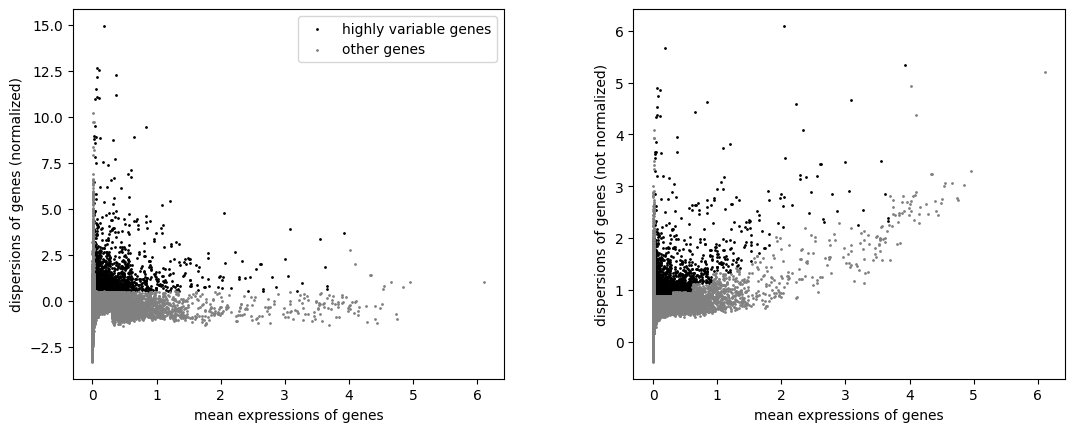

In [12]:
sc.pl.highly_variable_genes(mdata['rna'])

In [13]:
mdata['rna'].raw = mdata['rna']
sc.pp.scale(mdata['rna'], max_value=10)

/home/milo/.pyenv/versions/3.12.7/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [14]:
sc.pp.pca(mdata['rna'])
sc.pp.pca(mdata['prot'])

In [15]:
sc.pp.neighbors(mdata['rna'])
sc.pp.neighbors(mdata['prot'])

In [16]:
mdata.write(Path().home().joinpath("workspace", "scorphan", "tests", "5k_pbmc.h5mu"))

/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/milo/workspace/scorphan/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
